# Singular drift with parameter-evolving DTB

Run all cells in Jupyter or Colab. Dependencies: PyTorch, NumPy, and Matplotlib.

For $r=x_1-x_2$, the dynamics are
$$\dot x=b(x)=\left(-\frac{2}{r},-\frac{1}{r}\right).$$

The diagonal $x_1=x_2$ is singular. Initially, sample $c\sim U[-1,1]$ and
$r\sim U[1,2]$, then set $z=(c+2r,c+r)$. Use $T<0.5$ for this initial law.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import torch
from torch import nn
from torch.func import functional_call, jacrev, vmap

DEVICE = torch.device('cpu')  # 'cuda' also supports the float64 calculation.
DTYPE = torch.float64
torch.set_num_threads(min(4, torch.get_num_threads()))

SEED = 0
N = 512                     # Particles used for the tangent projection.
N_SNAPSHOT = 2048            # Independent labels used only for the heatmaps.
WIDTH = 16
DEPTH = 2
BASIS_SIZE = 128
RIDGE = 1e-6
H = 1e-3
T = 0.45
STOP_GAP = 0.02

In [2]:
def dynamic_drift(x):
    r = x[..., 0] - x[..., 1]
    if not torch.isfinite(x).all() or torch.any(r == 0):
        raise FloatingPointError('Drift is undefined at a nonfinite state or x1=x2.')
    return torch.stack((-2 / r, -1 / r), dim=-1)


def sample_initial(n, seed):
    generator = torch.Generator().manual_seed(seed)
    u = torch.rand(n, 2, generator=generator, dtype=DTYPE).to(DEVICE)
    c, r = 2*u[:, 0] - 1, 1 + u[:, 1]
    return torch.stack((c + 2*r, c + r), dim=-1)

## DTB update

Use the residual map $X_k(z)=T_{\theta_k}(z)=z+\mathrm{MLP}_{\theta_k}(z)$,
initialized to the identity. Keep one selected parameter subset $S$ and the
initial labels fixed. Recompute $J_k=\partial_{\theta_S}T_{\theta_k}(z)$ each step.

$$\alpha_k=\arg\min_\alpha\frac1N\|J_k\alpha-b(X_k)\|_2^2
+\eta\|\alpha\|_2^2,\qquad
\theta_{k+1,S}=\theta_{k,S}+h\alpha_k.$$

The next state is the updated map $T_{\theta_{k+1}}(z)$. The SVD below solves
this particle-normalized ridge problem directly.

In [3]:
class ResidualMap(nn.Module):
    def __init__(self, width, depth):
        super().__init__()
        layers = []
        for i in range(depth):
            layers += [nn.Linear(2 if i == 0 else width, width, dtype=DTYPE), nn.Tanh()]
        layers += [nn.Linear(width, 2, dtype=DTYPE)]
        self.net = nn.Sequential(*layers)
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, z):
        return z + self.net(z)


def map_at(theta, z, model):
    parameters, offset = {}, 0
    for name, p in model.named_parameters():
        parameters[name] = theta[offset:offset+p.numel()].reshape(p.shape)
        offset += p.numel()
    return functional_call(model, parameters, (z,))


def tangent_jacobian(theta, selected, z, model):
    def one(values, label):
        full = theta.index_copy(0, selected, values)
        return map_at(full, label, model)
    batch = vmap(jacrev(one, argnums=0), in_dims=(None, 0))
    return torch.cat([batch(theta[selected], part).detach()
                      for part in z.split(256)], dim=0)


def ridge_solve(jacobian, target, eta):
    n, d, m = jacobian.shape
    a = jacobian.reshape(n*d, m) / math.sqrt(n)
    y = target.reshape(-1) / math.sqrt(n)
    u, s, vh = torch.linalg.svd(a, full_matrices=False)
    return (vh.T @ ((s / (s.square() + eta)) * (u.T @ y))).detach()

In [4]:
def run_dtb(n=N, n_snapshot=N_SNAPSHOT, width=WIDTH, depth=DEPTH,
            basis_size=BASIS_SIZE, ridge=RIDGE, h=H, t_final=T,
            seed=SEED, stop_gap=STOP_GAP):
    if min(n, n_snapshot, width, depth, basis_size) < 1:
        raise ValueError('Sample counts and network dimensions must be positive.')
    if not all(math.isfinite(v) and v > 0 for v in (h, ridge, t_final, stop_gap)):
        raise ValueError('h, ridge, t_final, and stop_gap must be finite and positive.')
    if t_final >= 0.5:
        raise ValueError('Use T < 0.5 for this singular initial-value problem.')

    torch.manual_seed(seed)
    model = ResidualMap(width, depth).to(DEVICE)
    theta = torch.cat([p.detach().reshape(-1) for p in model.parameters()])
    if basis_size > theta.numel():
        raise ValueError('BASIS_SIZE exceeds the number of network parameters.')
    generator = torch.Generator().manual_seed(20000 + seed)
    selected = torch.randperm(theta.numel(), generator=generator)[:basis_size].sort().values.to(DEVICE)
    labels = sample_initial(n, 10000 + seed)
    snapshot_labels = sample_initial(n_snapshot, 314159)

    steps = math.ceil(t_final / h)
    grid = np.linspace(0.0, t_final, steps + 1)
    snapshot_steps = set(np.unique(np.rint(np.linspace(0, steps, 6)).astype(int)))
    snapshot_times, snapshots = [], []
    diagnostic_times, projection_error, alpha_history = [], [], []
    status = 'completed'

    for k, t in enumerate(grid):
        x = map_at(theta, labels, model).detach()
        cloud = map_at(theta, snapshot_labels, model).detach()
        if k in snapshot_steps:
            snapshot_times.append(float(t))
            snapshots.append(cloud.cpu().clone())
        if k == steps:
            break

        current_gap = min(float((q[:, 0]-q[:, 1]).min()) for q in (x, cloud))
        if current_gap <= stop_gap:
            status = f'stopped at t={t:.4f}: minimum gap reached STOP_GAP'
            break

        # Project the drift into the selected tangent space at theta_k.
        J = tangent_jacobian(theta, selected, labels, model)
        target = dynamic_drift(x)
        try:
            alpha = ridge_solve(J, target, ridge)
        except torch.linalg.LinAlgError:
            status = f'stopped at t={t:.4f}: SVD failed'
            break
        projected = torch.einsum('ndm,m->nd', J, alpha)
        error = (projected-target).square().sum(-1).mean().sqrt()

        # Only selected parameters move; the state is the new nonlinear map.
        step = float(grid[k+1] - t)
        proposed_theta = theta.index_add(0, selected, step*alpha)
        proposed_train = map_at(proposed_theta, labels, model).detach()
        proposed_cloud = map_at(proposed_theta, snapshot_labels, model).detach()
        if not all(torch.isfinite(q).all() and torch.all(q[:, 0]-q[:, 1] > stop_gap)
                   for q in (proposed_train, proposed_cloud)):
            status = f'stopped at t={t:.4f}: rejected a step toward the singular diagonal'
            break

        diagnostic_times.append(float(t))
        projection_error.append(float(error))
        alpha_history.append(alpha.cpu().clone())
        theta = proposed_theta.detach()

    # If stopped between scheduled snapshots, show the actual last valid state.
    if not snapshot_times or abs(snapshot_times[-1]-float(t)) > 1e-12:
        snapshot_times.append(float(t))
        snapshots.append(cloud.cpu().clone())
    return {
        'snapshot_times': np.asarray(snapshot_times), 'snapshots': torch.stack(snapshots),
        'diagnostic_times': np.asarray(diagnostic_times),
        'projection_error': np.asarray(projection_error),
        'alpha': torch.stack(alpha_history) if alpha_history else torch.empty(0, basis_size),
        'theta': theta, 'selected': selected, 'model': model,
        'labels': labels, 'snapshot_labels': snapshot_labels, 'status': status,
    }


result = run_dtb()
print(f"DTB: {result['status']}; last snapshot t={result['snapshot_times'][-1]:.3f}")

DTB: completed; last snapshot t=0.450


## Snapshots and coefficient trajectories

Each point keeps the color of its **initial coordinate gap**
$r_0=|x_1(0)-x_2(0)|$ in every snapshot: purple is a smaller initial gap,
and yellow is a larger initial gap. The shared colorbar is fixed across time.
The faint gray heatmap shows particle density, and the dashed line marks $x_1=x_2$.

For this drift, $\dot r=-1/r$ on the positive-gap branch. Larger gaps therefore
close more slowly; follow the fixed point colors to see this in the DTB snapshots.

The projection error is $\sqrt{N^{-1}\sum_n\|(J_k\alpha_k)_n-b(X_k(z_n))\|^2}$.
The alpha curve shows $\|\alpha_k\|_2$. Both are plotted at the time of the
corresponding tangent solve.


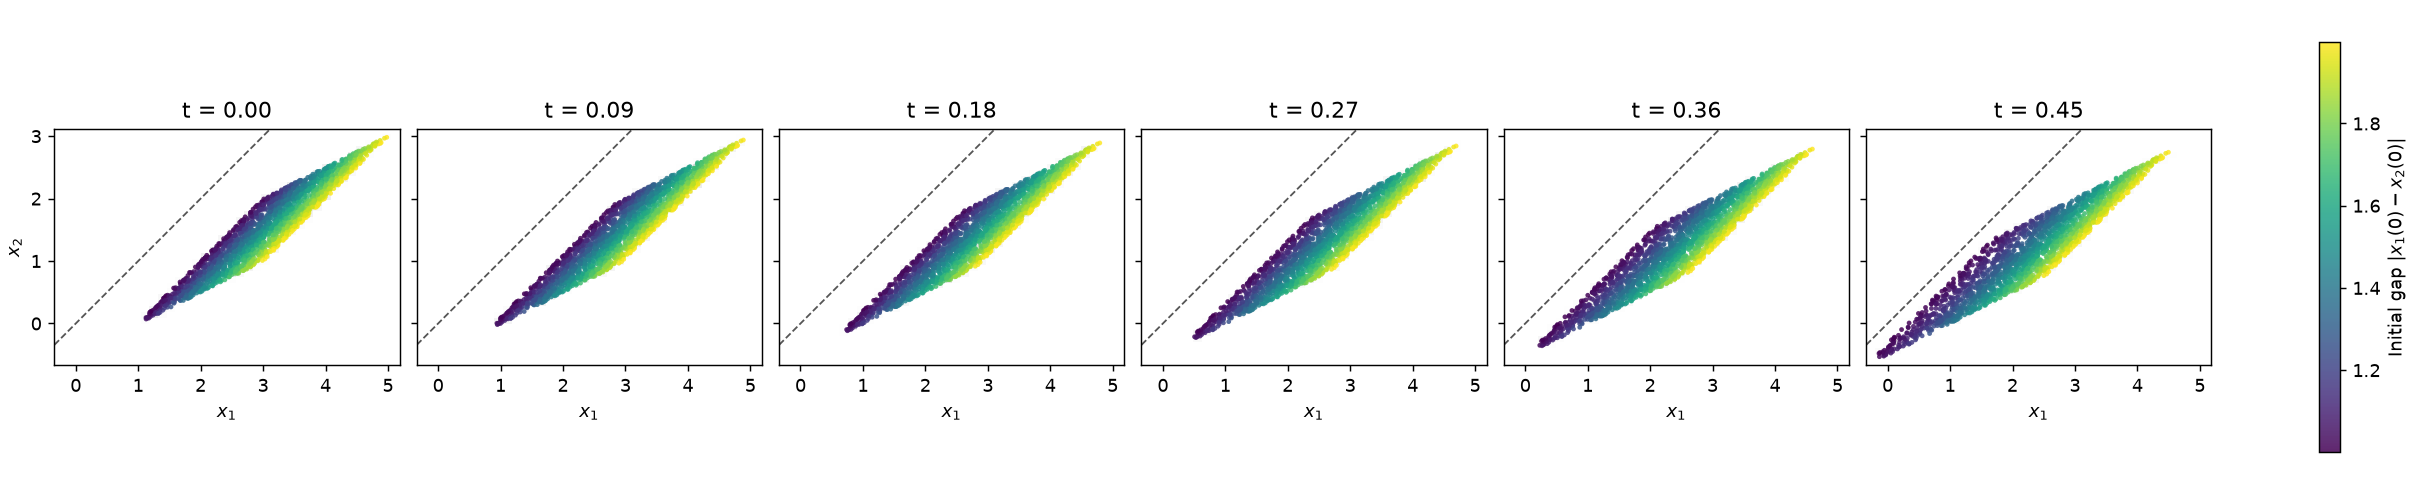

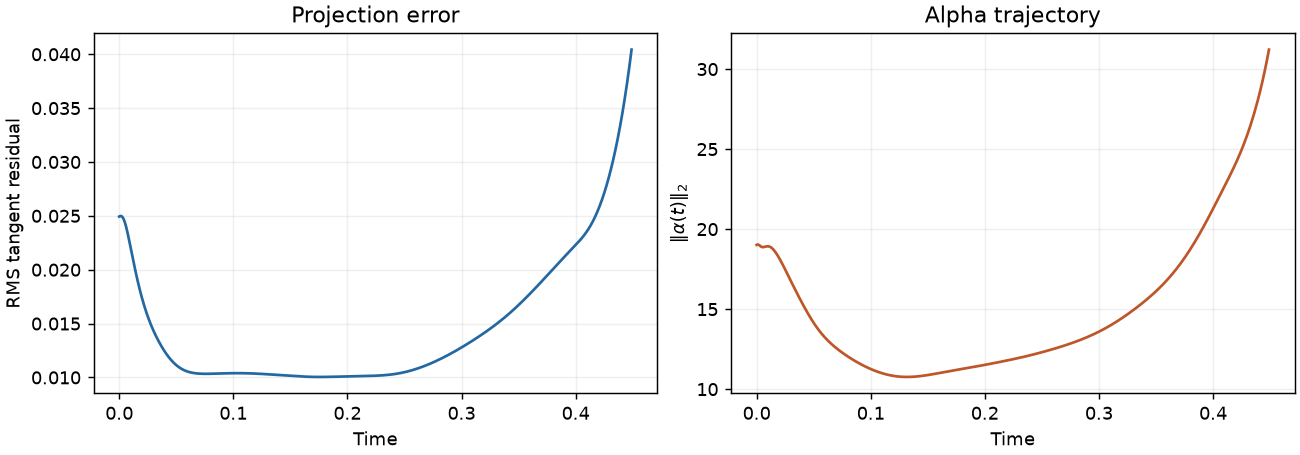

In [5]:
clouds = result['snapshots'].numpy()
x_min, x_max = clouds[..., 0].min(), clouds[..., 0].max()
y_min, y_max = clouds[..., 1].min(), clouds[..., 1].max()
x_pad, y_pad = max(0.1, 0.04*(x_max-x_min)), max(0.1, 0.04*(y_max-y_min))
x_edges = np.linspace(x_min-x_pad, x_max+x_pad, 41)
y_edges = np.linspace(y_min-y_pad, y_max+y_pad, 41)
bin_area = np.diff(x_edges)[:, None] * np.diff(y_edges)[None, :]
densities = [np.histogram2d(q[:, 0], q[:, 1], bins=(x_edges, y_edges))[0]
             / (len(q)*bin_area) for q in clouds]
density_normalization = Normalize(vmin=0, vmax=max(d.max() for d in densities))
# Color follows particle identity: compute it once from the ORIGINAL labels.
initial_points = result['snapshot_labels'].detach().cpu().numpy()
initial_gap = np.abs(initial_points[:, 0] - initial_points[:, 1])
gap_normalization = Normalize(vmin=initial_gap.min(), vmax=initial_gap.max())

fig_snapshots, axes = plt.subplots(1, len(clouds), figsize=(3.1*len(clouds), 3.8),
                                  sharex=True, sharey=True, squeeze=False,
                                  layout='constrained')
for ax, t, density, points in zip(axes.flat, result['snapshot_times'], densities, clouds):
    ax.pcolormesh(x_edges, y_edges, density.T, cmap='Greys', alpha=0.22,
                  norm=density_normalization, shading='auto', rasterized=True)
    colored_points = ax.scatter(points[:, 0], points[:, 1], c=initial_gap,
                                cmap='viridis', norm=gap_normalization,
                                s=7, alpha=0.85, linewidths=0, rasterized=True)
    diagonal = [max(x_edges[0], y_edges[0]), min(x_edges[-1], y_edges[-1])]
    ax.plot(diagonal, diagonal, '--', color='#555555', lw=1)
    ax.set(xlim=(x_edges[0], x_edges[-1]), ylim=(y_edges[0], y_edges[-1]),
           title=f't = {t:.2f}', xlabel='$x_1$')
    ax.set_aspect('equal', adjustable='box')
axes[0, 0].set_ylabel('$x_2$')
fig_snapshots.colorbar(colored_points, ax=axes.ravel().tolist(),
                       label=r'Initial gap $|x_1(0)-x_2(0)|$', shrink=0.85)
plt.show()

fig_diagnostics, axes = plt.subplots(1, 2, figsize=(10, 3.5), layout='constrained')
axes[0].plot(result['diagnostic_times'], result['projection_error'], color='#2468A2')
axes[0].set(title='Projection error', xlabel='Time', ylabel='RMS tangent residual')
axes[1].plot(result['diagnostic_times'], result['alpha'].norm(dim=1).numpy(), color='#BD572A')
axes[1].set(title='Alpha trajectory', xlabel='Time', ylabel=r'$\|\alpha(t)\|_2$')
for ax in axes:
    ax.grid(alpha=0.2)
plt.show()